In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')
 
print("All libraries imported successfully ✅")

All libraries imported successfully ✅


In [11]:
PATH = 'C:/Users/Lenovo/Downloads/RestoDataset/foodDemand_train'
 
train  = pd.read_csv(PATH + '/train.csv')
center = pd.read_csv(PATH + '/fulfilment_center_info.csv')
meal   = pd.read_csv(PATH + '/meal_info.csv')
 
print(f"Train Shape   : {train.shape}")
print(f"Center Shape  : {center.shape}")
print(f"Meal Shape    : {meal.shape}")
 
# ── CELL 3: Preview Each File ────────────────────────────────
print("=== TRAIN (first 5 rows) ===")
print(train.head())
 
print("\n=== FULFILMENT CENTER ===")
print(center.head())
 
print("\n=== MEAL INFO ===")
print(meal.head())

Train Shape   : (456548, 9)
Center Shape  : (77, 5)
Meal Shape    : (51, 3)
=== TRAIN (first 5 rows) ===
        id  week  center_id  meal_id  checkout_price  base_price  \
0  1379560     1         55     1885          136.83      152.29   
1  1466964     1         55     1993          136.83      135.83   
2  1346989     1         55     2539          134.86      135.86   
3  1338232     1         55     2139          339.50      437.53   
4  1448490     1         55     2631          243.50      242.50   

   emailer_for_promotion  homepage_featured  num_orders  
0                      0                  0         177  
1                      0                  0         270  
2                      0                  0         189  
3                      0                  0          54  
4                      0                  0          40  

=== FULFILMENT CENTER ===
   center_id  city_code  region_code center_type  op_area
0         11        679           56      TYPE_A     

In [12]:
df = train.merge(center, on='center_id', how='left') \
          .merge(meal,   on='meal_id',   how='left')
 
print(f"\nMerged Dataset Shape : {df.shape}")
print(f"Columns              : {df.columns.tolist()}")
print(df.head(3))
 
# Save merged dataset
df.to_csv('merged_food_demand.csv', index=False)
print("\nMerged dataset saved as merged_food_demand.csv ✅")


Merged Dataset Shape : (456548, 15)
Columns              : ['id', 'week', 'center_id', 'meal_id', 'checkout_price', 'base_price', 'emailer_for_promotion', 'homepage_featured', 'num_orders', 'city_code', 'region_code', 'center_type', 'op_area', 'category', 'cuisine']
        id  week  center_id  meal_id  checkout_price  base_price  \
0  1379560     1         55     1885          136.83      152.29   
1  1466964     1         55     1993          136.83      135.83   
2  1346989     1         55     2539          134.86      135.86   

   emailer_for_promotion  homepage_featured  num_orders  city_code  \
0                      0                  0         177        647   
1                      0                  0         270        647   
2                      0                  0         189        647   

   region_code center_type  op_area   category cuisine  
0           56      TYPE_C      2.0  Beverages    Thai  
1           56      TYPE_C      2.0  Beverages    Thai  
2      

In [13]:
print("=" * 55)
print("DATA QUALITY REPORT")
print("=" * 55)
print(f"\nTotal Records     : {len(df):,}")
print(f"Total Columns     : {df.shape[1]}")
print(f"\nMissing Values:")
print(df.isnull().sum())
print(f"\nDuplicate Rows    : {df.duplicated().sum()}")
print(f"\nData Types:")
print(df.dtypes)
print(f"\nBasic Statistics:")
print(df.describe())

DATA QUALITY REPORT

Total Records     : 456,548
Total Columns     : 15

Missing Values:
id                       0
week                     0
center_id                0
meal_id                  0
checkout_price           0
base_price               0
emailer_for_promotion    0
homepage_featured        0
num_orders               0
city_code                0
region_code              0
center_type              0
op_area                  0
category                 0
cuisine                  0
dtype: int64

Duplicate Rows    : 0

Data Types:
id                         int64
week                       int64
center_id                  int64
meal_id                    int64
checkout_price           float64
base_price               float64
emailer_for_promotion      int64
homepage_featured          int64
num_orders                 int64
city_code                  int64
region_code                int64
center_type                  str
op_area                  float64
category                    

In [14]:
print(f"\nWeek Range        : Week {df['week'].min()} to Week {df['week'].max()}")
print(f"Total Weeks       : {df['week'].nunique()}")
print(f"Total Centers     : {df['center_id'].nunique()}")
print(f"Total Meals       : {df['meal_id'].nunique()}")
print(f"Total Categories  : {df['category'].nunique()} → {df['category'].unique()}")
print(f"Total Cuisines    : {df['cuisine'].nunique()} → {df['cuisine'].unique()}")
print(f"Center Types      : {df['center_type'].unique()}")


Week Range        : Week 1 to Week 145
Total Weeks       : 145
Total Centers     : 77
Total Meals       : 51
Total Categories  : 14 → <StringArray>
[   'Beverages',    'Rice Bowl',     'Starters',        'Pasta',
     'Sandwich',      'Biryani',       'Extras',        'Pizza',
      'Seafood', 'Other Snacks',       'Desert',         'Soup',
        'Salad',         'Fish']
Length: 14, dtype: str
Total Cuisines    : 4 → <StringArray>
['Thai', 'Indian', 'Italian', 'Continental']
Length: 4, dtype: str
Center Types      : <StringArray>
['TYPE_C', 'TYPE_B', 'TYPE_A']
Length: 3, dtype: str


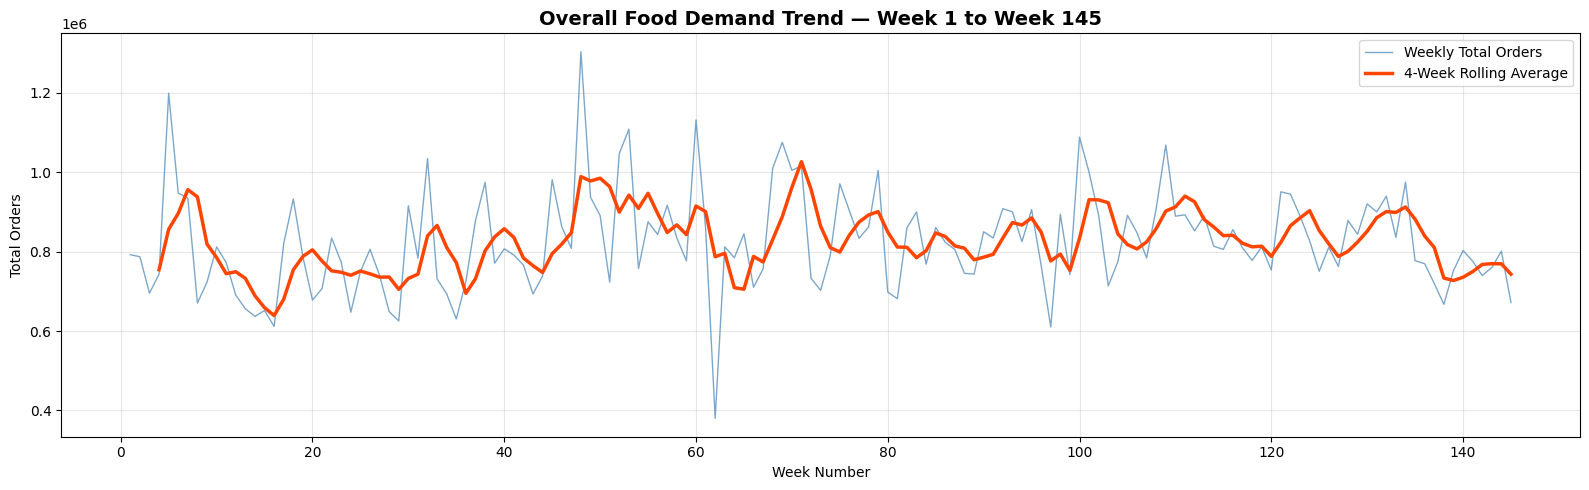

Saved: demand_trend.png ✅


In [15]:
weekly_demand = df.groupby('week')['num_orders'].sum().reset_index()
 
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(weekly_demand['week'], weekly_demand['num_orders'],
        color='steelblue', linewidth=1, alpha=0.7, label='Weekly Total Orders')
 
# Rolling average
rolling = weekly_demand['num_orders'].rolling(window=4).mean()
ax.plot(weekly_demand['week'], rolling,
        color='orangered', linewidth=2.5, label='4-Week Rolling Average')
 
ax.set_title('Overall Food Demand Trend — Week 1 to Week 145',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Week Number')
ax.set_ylabel('Total Orders')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('demand_trend.png', dpi=150)
plt.show()
print("Saved: demand_trend.png ✅")

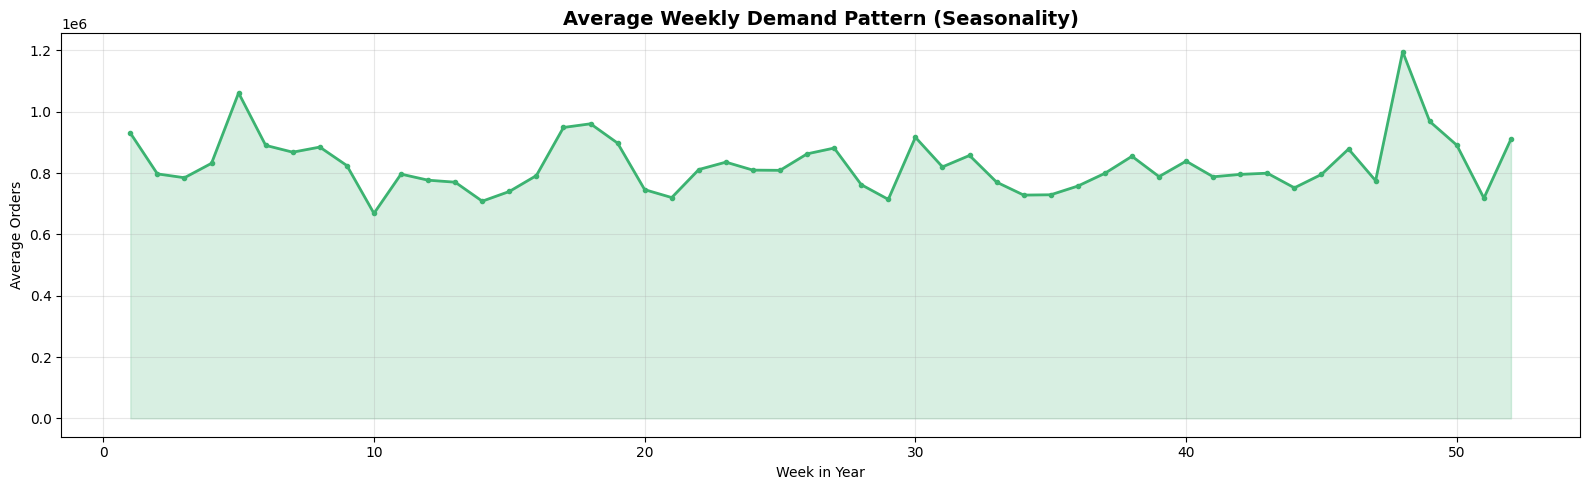

Saved: weekly_seasonality.png ✅


In [16]:
weekly_demand['week_in_year'] = ((weekly_demand['week'] - 1) % 52) + 1
seasonal_avg = weekly_demand.groupby('week_in_year')['num_orders'].mean()
 
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(seasonal_avg.index, seasonal_avg.values,
        color='mediumseagreen', linewidth=2, marker='o', markersize=3)
ax.fill_between(seasonal_avg.index, seasonal_avg.values,
                alpha=0.2, color='mediumseagreen')
ax.set_title('Average Weekly Demand Pattern (Seasonality)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Week in Year')
ax.set_ylabel('Average Orders')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('weekly_seasonality.png', dpi=150)
plt.show()
print("Saved: weekly_seasonality.png ✅")

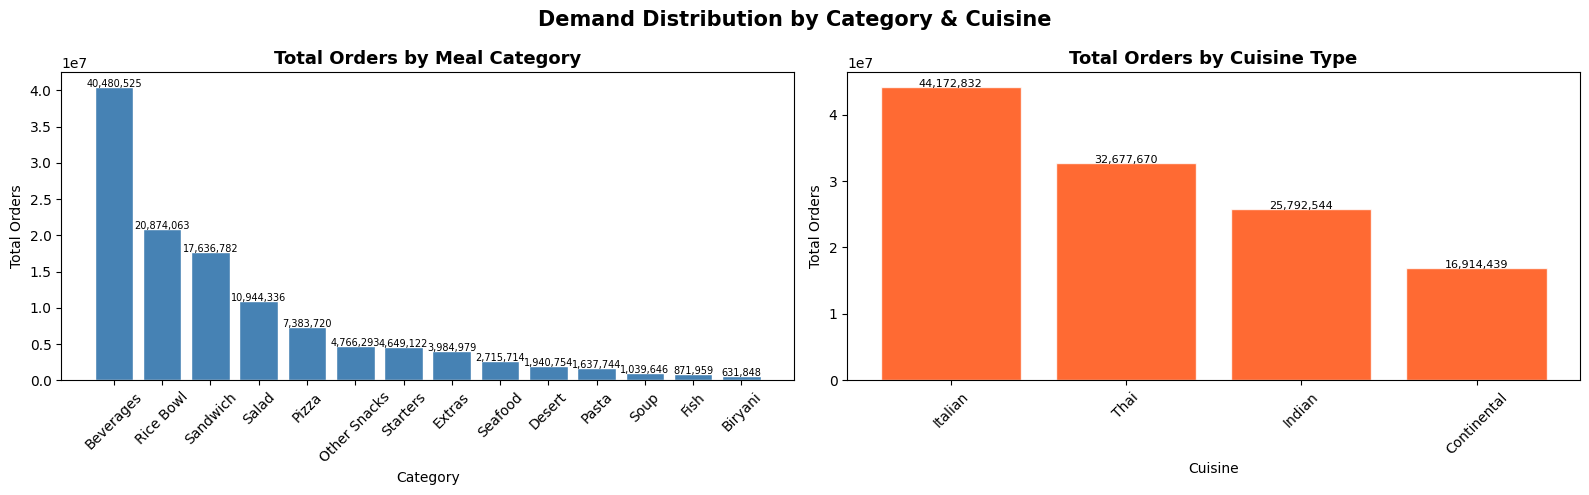

Saved: category_cuisine_demand.png ✅


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
 
# Total orders by category
cat_demand = df.groupby('category')['num_orders'].sum().sort_values(ascending=False)
axes[0].bar(cat_demand.index, cat_demand.values, color='steelblue', edgecolor='white')
axes[0].set_title('Total Orders by Meal Category', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Total Orders')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(cat_demand.values):
    axes[0].text(i, v + 1000, f'{v:,.0f}', ha='center', fontsize=7)
 
# Total orders by cuisine
cuisine_demand = df.groupby('cuisine')['num_orders'].sum().sort_values(ascending=False)
axes[1].bar(cuisine_demand.index, cuisine_demand.values,
            color='orangered', edgecolor='white', alpha=0.8)
axes[1].set_title('Total Orders by Cuisine Type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Cuisine')
axes[1].set_ylabel('Total Orders')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(cuisine_demand.values):
    axes[1].text(i, v + 1000, f'{v:,.0f}', ha='center', fontsize=8)
 
plt.suptitle('Demand Distribution by Category & Cuisine', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('category_cuisine_demand.png', dpi=150)
plt.show()
print("Saved: category_cuisine_demand.png ✅")

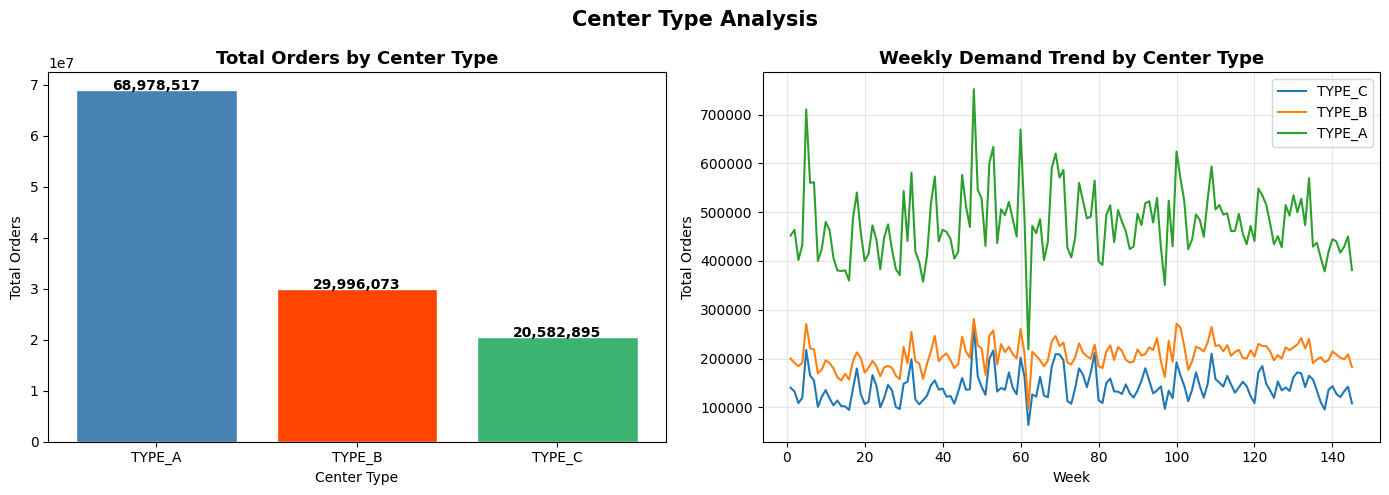

Saved: center_type_analysis.png ✅


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
center_demand = df.groupby('center_type')['num_orders'].sum().sort_values(ascending=False)
axes[0].bar(center_demand.index, center_demand.values,
            color=['steelblue', 'orangered', 'mediumseagreen'], edgecolor='white')
axes[0].set_title('Total Orders by Center Type', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Center Type')
axes[0].set_ylabel('Total Orders')
for i, v in enumerate(center_demand.values):
    axes[0].text(i, v + 1000, f'{v:,.0f}', ha='center', fontweight='bold')
 
# Weekly trend by center type
for ctype in df['center_type'].unique():
    cdata = df[df['center_type'] == ctype].groupby('week')['num_orders'].sum()
    axes[1].plot(cdata.index, cdata.values, label=ctype, linewidth=1.5)
 
axes[1].set_title('Weekly Demand Trend by Center Type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Week')
axes[1].set_ylabel('Total Orders')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
 
plt.suptitle('Center Type Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('center_type_analysis.png', dpi=150)
plt.show()
print("Saved: center_type_analysis.png ✅")

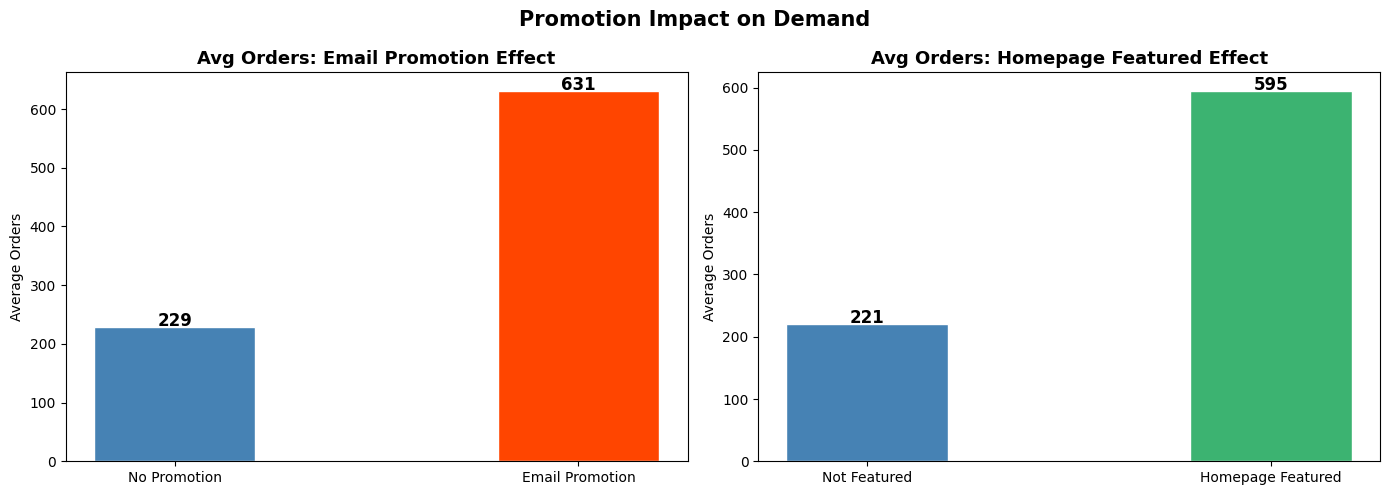

Saved: promotion_impact.png ✅


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Email promotion effect
email_effect = df.groupby('emailer_for_promotion')['num_orders'].mean()
axes[0].bar(['No Promotion', 'Email Promotion'], email_effect.values,
            color=['steelblue', 'orangered'], edgecolor='white', width=0.4)
axes[0].set_title('Avg Orders: Email Promotion Effect', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Average Orders')
for i, v in enumerate(email_effect.values):
    axes[0].text(i, v + 1, f'{v:.0f}', ha='center', fontweight='bold', fontsize=12)
 
# Homepage featured effect
home_effect = df.groupby('homepage_featured')['num_orders'].mean()
axes[1].bar(['Not Featured', 'Homepage Featured'], home_effect.values,
            color=['steelblue', 'mediumseagreen'], edgecolor='white', width=0.4)
axes[1].set_title('Avg Orders: Homepage Featured Effect', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Average Orders')
for i, v in enumerate(home_effect.values):
    axes[1].text(i, v + 1, f'{v:.0f}', ha='center', fontweight='bold', fontsize=12)
 
plt.suptitle('Promotion Impact on Demand', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('promotion_impact.png', dpi=150)
plt.show()
print("Saved: promotion_impact.png ✅")

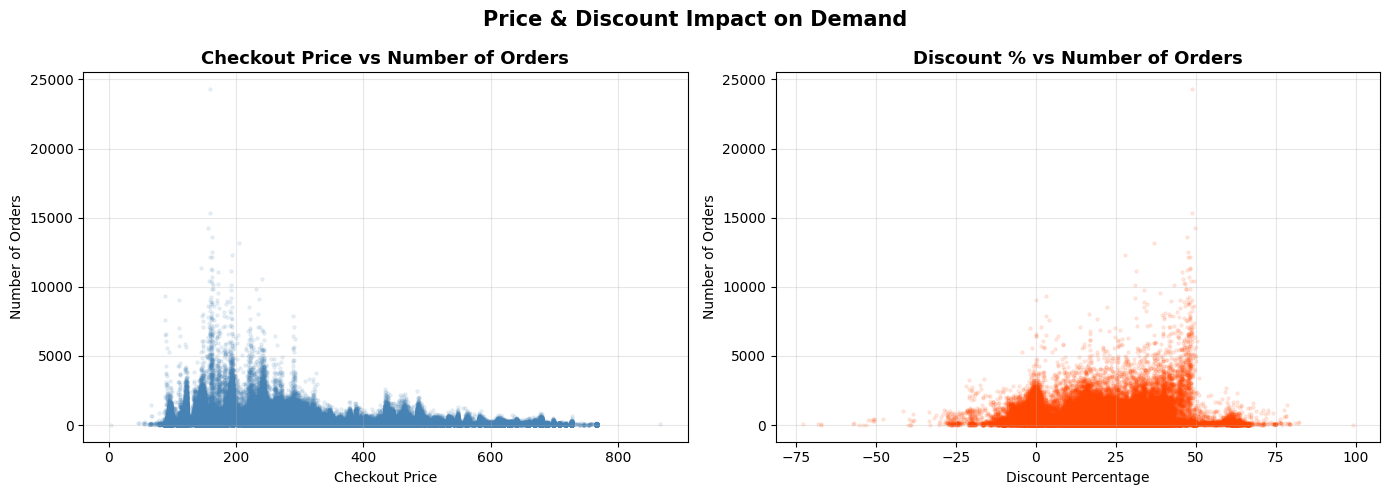

Saved: price_analysis.png ✅


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
axes[0].scatter(df['checkout_price'], df['num_orders'],
                alpha=0.1, color='steelblue', s=5)
axes[0].set_title('Checkout Price vs Number of Orders', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Checkout Price')
axes[0].set_ylabel('Number of Orders')
axes[0].grid(True, alpha=0.3)
 
# Discount effect
df['discount'] = df['base_price'] - df['checkout_price']
df['discount_pct'] = (df['discount'] / df['base_price']) * 100
axes[1].scatter(df['discount_pct'], df['num_orders'],
                alpha=0.1, color='orangered', s=5)
axes[1].set_title('Discount % vs Number of Orders', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Discount Percentage')
axes[1].set_ylabel('Number of Orders')
axes[1].grid(True, alpha=0.3)
 
plt.suptitle('Price & Discount Impact on Demand', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('price_analysis.png', dpi=150)
plt.show()
print("Saved: price_analysis.png ✅")

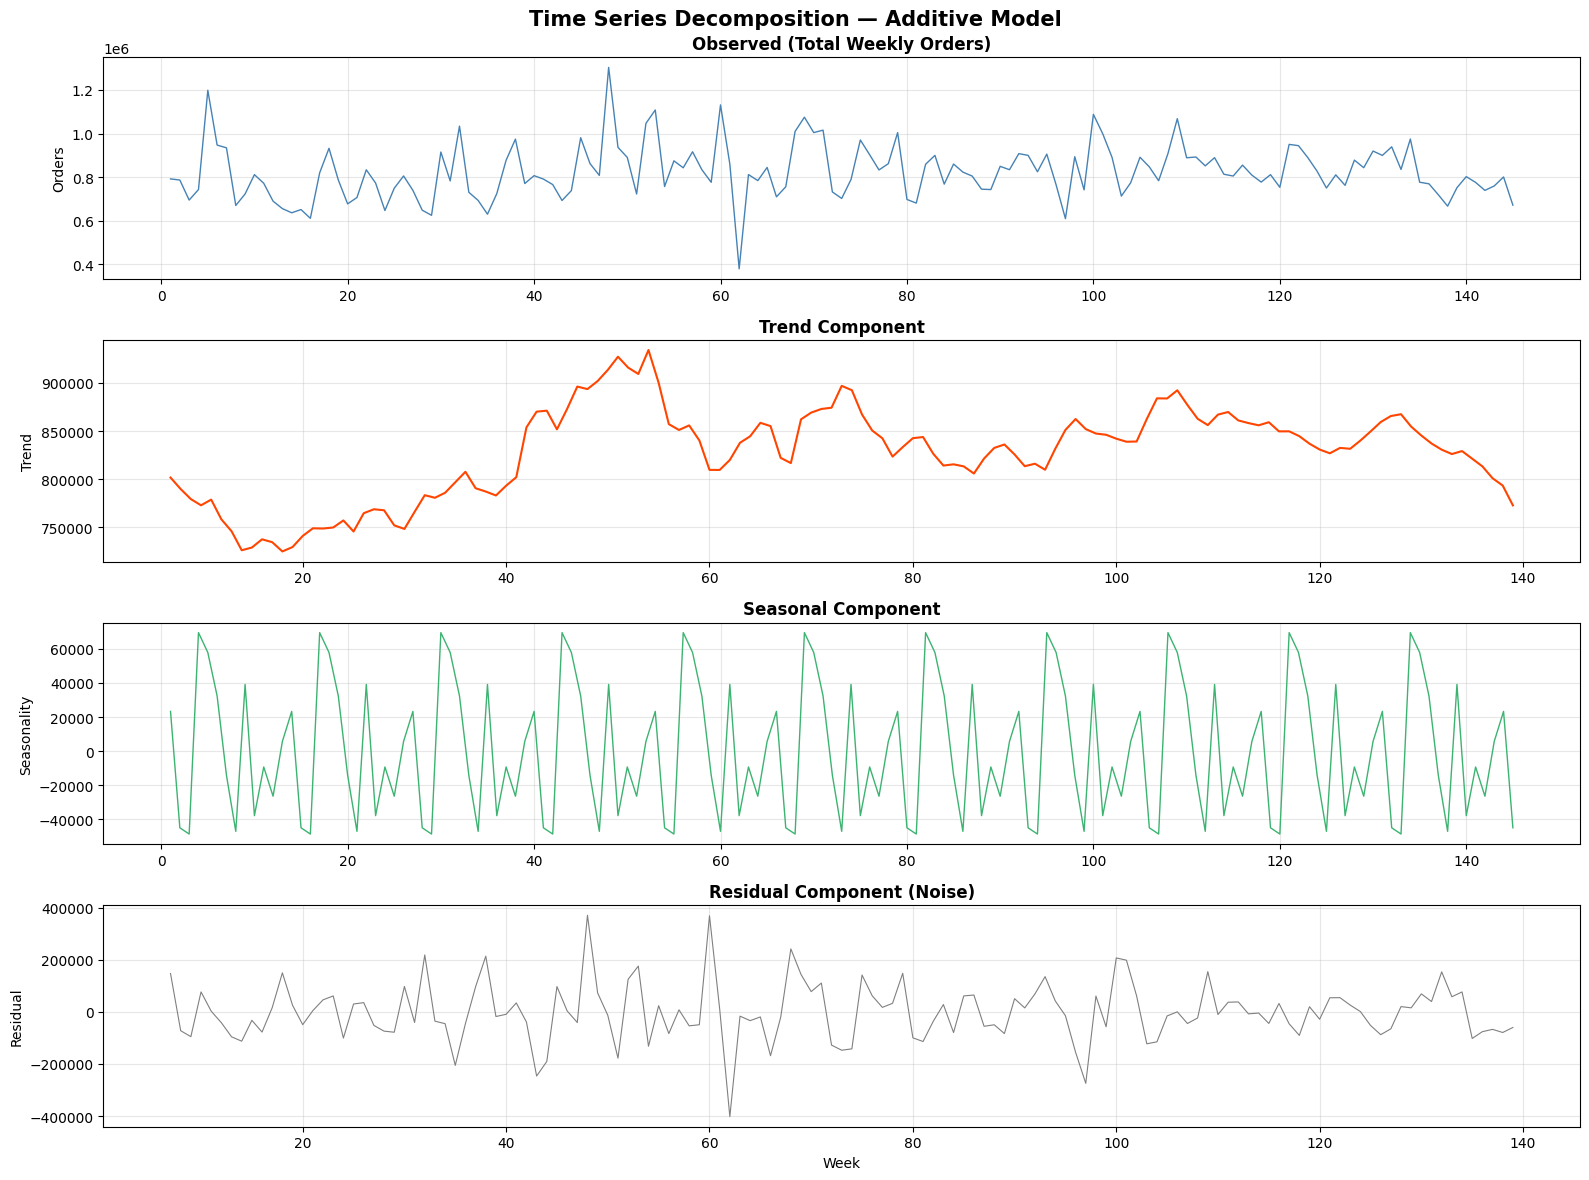

Saved: decomposition.png ✅


In [21]:
# ── CELL 13: Time Series Decomposition ───────────────────────
# Use total weekly demand for decomposition
ts = weekly_demand.set_index('week')['num_orders']
 
decomposition = seasonal_decompose(ts, model='additive', period=13)
 
fig, axes = plt.subplots(4, 1, figsize=(16, 12))
 
axes[0].plot(decomposition.observed,   color='steelblue',     linewidth=1)
axes[0].set_title('Observed (Total Weekly Orders)', fontweight='bold')
axes[0].set_ylabel('Orders')
 
axes[1].plot(decomposition.trend,      color='orangered',     linewidth=1.5)
axes[1].set_title('Trend Component',                          fontweight='bold')
axes[1].set_ylabel('Trend')
 
axes[2].plot(decomposition.seasonal,   color='mediumseagreen',linewidth=1)
axes[2].set_title('Seasonal Component',                       fontweight='bold')
axes[2].set_ylabel('Seasonality')
 
axes[3].plot(decomposition.resid,      color='gray',          linewidth=0.8)
axes[3].set_title('Residual Component (Noise)',               fontweight='bold')
axes[3].set_ylabel('Residual')
axes[3].set_xlabel('Week')
 
for ax in axes:
    ax.grid(True, alpha=0.3)
 
plt.suptitle('Time Series Decomposition — Additive Model',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('decomposition.png', dpi=150)
plt.show()
print("Saved: decomposition.png ✅")

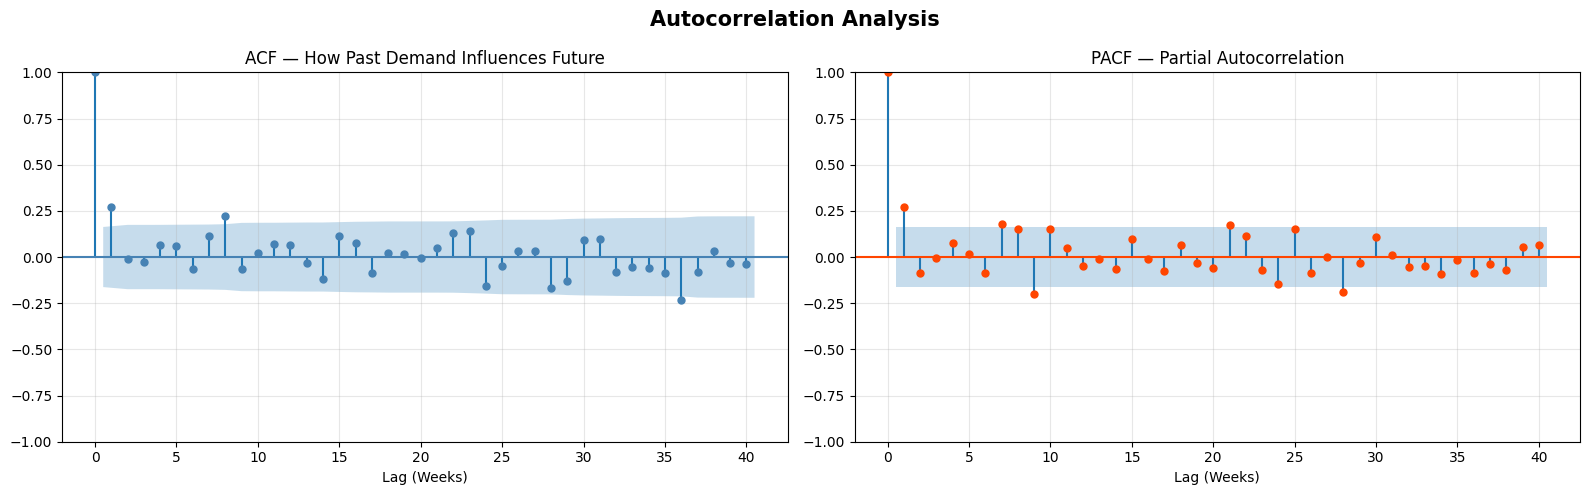

Saved: autocorrelation.png ✅


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
 
plot_acf(ts, ax=axes[0], lags=40,
         title='ACF — How Past Demand Influences Future',
         color='steelblue')
plot_pacf(ts, ax=axes[1], lags=40,
          title='PACF — Partial Autocorrelation',
          color='orangered')
 
axes[0].set_xlabel('Lag (Weeks)')
axes[1].set_xlabel('Lag (Weeks)')
axes[0].grid(True, alpha=0.3)
axes[1].grid(True, alpha=0.3)
 
plt.suptitle('Autocorrelation Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('autocorrelation.png', dpi=150)
plt.show()
print("Saved: autocorrelation.png ✅")

In [27]:
result = adfuller(ts.dropna())
 
print("=" * 55)
print("AUGMENTED DICKEY-FULLER STATIONARITY TEST")
print("=" * 55)
print(f"ADF Statistic  : {result[0]:.4f}")
print(f"p-value        : {result[1]:.4f}")
print(f"Critical Values:")
for key, val in result[4].items():
    print(f"   {key}  :  {val:.4f}")
 
if result[1] < 0.05:
    print("\nResult: Series is STATIONARY ✅ (p < 0.05)")
    print("Suitable for forecasting directly")
else:
    print("\nResult: Series is NON-STATIONARY ⚠️")
   

AUGMENTED DICKEY-FULLER STATIONARITY TEST
ADF Statistic  : -2.5429
p-value        : 0.1054
Critical Values:
   1%  :  -3.4797
   5%  :  -2.8832
   10%  :  -2.5783

Result: Series is NON-STATIONARY ⚠️


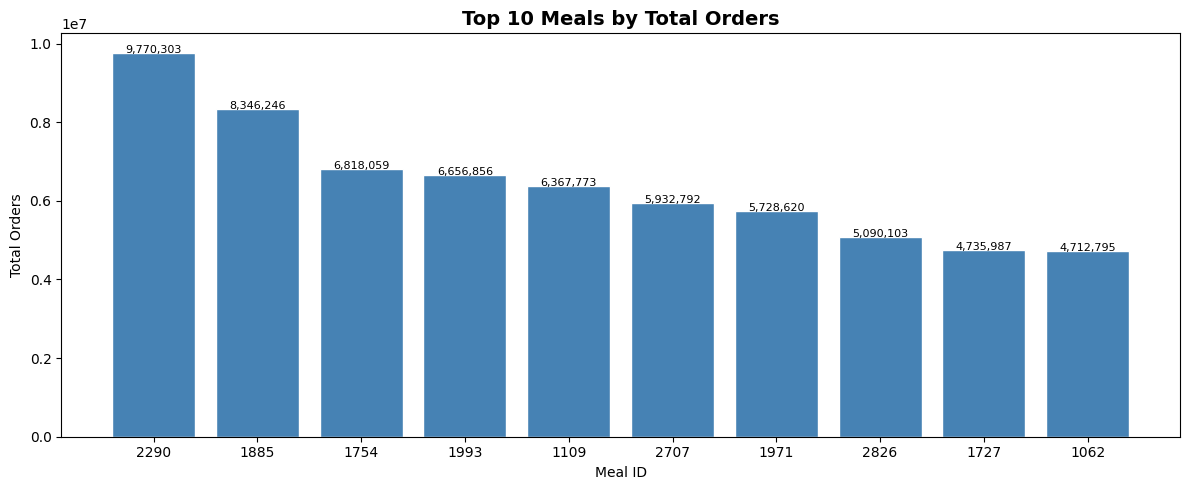

Saved: top_meals.png ✅


In [24]:
top_meals = df.groupby('meal_id')['num_orders'].sum() \
              .sort_values(ascending=False).head(10)
 
plt.figure(figsize=(12, 5))
plt.bar(top_meals.index.astype(str), top_meals.values,
        color='steelblue', edgecolor='white')
plt.title('Top 10 Meals by Total Orders', fontsize=14, fontweight='bold')
plt.xlabel('Meal ID')
plt.ylabel('Total Orders')
for i, v in enumerate(top_meals.values):
    plt.text(i, v + 500, f'{v:,.0f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('top_meals.png', dpi=150)
plt.show()
print("Saved: top_meals.png ✅")

In [26]:
print("\n" + "=" * 55)
print("WEEK 1 COMPLETE — SUMMARY")
print("=" * 55)
print(f"  Total Records       : {len(df):,}")
print(f"  Total Weeks         : {df['week'].nunique()}")
print(f"  Total Centers       : {df['center_id'].nunique()}")
print(f"  Total Meals         : {df['meal_id'].nunique()}")
print(f"  Total Categories    : {df['category'].nunique()}")
print(f"  Missing Values      : {df.isnull().sum().sum()} ✅")
print(f"  Avg Orders per Week : {weekly_demand['num_orders'].mean():,.0f}")
print(f"  Max Demand Week     : Week {weekly_demand.loc[weekly_demand['num_orders'].idxmax(), 'week']}")
print(f"  Min Demand Week     : Week {weekly_demand.loc[weekly_demand['num_orders'].idxmin(), 'week']}")
print(f"\nOutputs Saved:")
print(f"  merged_food_demand.csv")
print(f"  demand_trend.png")
print(f"  weekly_seasonality.png")
print(f"  category_cuisine_demand.png")
print(f"  center_type_analysis.png")
print(f"  promotion_impact.png")
print(f"  price_analysis.png")
print(f"  decomposition.png")
print(f"  autocorrelation.png")
print(f"  top_meals.png")


WEEK 1 COMPLETE — SUMMARY
  Total Records       : 456,548
  Total Weeks         : 145
  Total Centers       : 77
  Total Meals         : 51
  Total Categories    : 14
  Missing Values      : 0 ✅
  Avg Orders per Week : 824,534
  Max Demand Week     : Week 48
  Min Demand Week     : Week 62

Outputs Saved:
  merged_food_demand.csv
  demand_trend.png
  weekly_seasonality.png
  category_cuisine_demand.png
  center_type_analysis.png
  promotion_impact.png
  price_analysis.png
  decomposition.png
  autocorrelation.png
  top_meals.png
